<a href="https://colab.research.google.com/github/cluquezDS/Deep-Learning/blob/main/01_comparacion_optimizadores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align:center; padding:4px 10px 28px 10px; margin:0 0 8px 0; border-bottom:1px solid #dbe6f0;">
<p style="margin:0 0 12px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:12px; letter-spacing:3px; text-transform:uppercase; color:#2C5F8A; font-weight:700;">Deep Learning</p>
<h1 style="margin:0 0 16px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:30px; line-height:1.3; color:#1B2A4A; font-weight:700;">Comparación de Optimizadores: SGD, RMSProp y Adam</h1>
<div style="width:64px; height:3px; margin:0 auto 18px auto; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C);"></div>
<p style="margin:0 0 18px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:15px; color:#2C5F8A; font-weight:700; letter-spacing:.3px; text-align:center;">Carolina Luque</p>
<p style="margin:0 auto; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14.5px; line-height:1.65; color:#44586e; max-width:560px;">Implementación desde cero con NumPy de una red neuronal multicapa (MLP). Compara la velocidad y la estabilidad de convergencia de tres optimizadores: <strong>SGD</strong>, <strong>RMSProp</strong> y <strong>Adam</strong>. Los tres se evalúan sobre el mismo problema de clasificación no lineal. Se mide el número de épocas necesario para converger y también el tiempo real de entrenamiento.</p>
</div>

<div style="background:#EAF1F8; border-left:4px solid #2C5F8A; border-radius:0 10px 10px 0; padding:18px 22px; margin:24px 0;">
<p style="margin:0 0 8px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:12.5px; font-weight:700; letter-spacing:1px; text-transform:uppercase; color:#2C5F8A;">Contexto del problema</p>
<p style="margin:0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14.5px; line-height:1.65; color:#1B2A4A;">Elegir un optimizador no es un detalle menor. La misma arquitectura, entrenada con los mismos datos y el mismo número de épocas, puede converger en pocas iteraciones o quedarse estancada. Todo depende de cómo se actualicen los pesos. En este notebook entrenamos <strong>tres veces la misma MLP</strong>: una capa oculta, los mismos datos y el mismo <code>batch_size</code>. Solo cambiamos el optimizador. Así respondemos dos preguntas prácticas: &iquest;cuál converge en menos épocas? &iquest;Cuál es más rápido en tiempo de reloj (<em>wall-clock</em>)? Estas dos nociones de &ldquo;velocidad&rdquo; no siempre coinciden.</p>
</div>

<div style="background:#ffffff; border:1px solid #dbe6f0; border-radius:10px; padding:22px 26px; margin:24px 0;">
<p style="margin:0 0 14px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:12.5px; font-weight:700; letter-spacing:1px; text-transform:uppercase; color:#2C5F8A;">Tabla de contenido</p>
<ol style="margin:0; padding-left:22px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14.5px; line-height:2; color:#1B2A4A;">
<li><a href="#seccion-1" style="color:#2C5F8A; text-decoration:none; font-weight:600;">Datos</a></li>
<li><a href="#seccion-2" style="color:#2C5F8A; text-decoration:none; font-weight:600;">Implementación de la clase MLP</a></li>
<li><a href="#seccion-3" style="color:#2C5F8A; text-decoration:none; font-weight:600;">Experimento comparativo</a></li>
<li><a href="#seccion-4" style="color:#2C5F8A; text-decoration:none; font-weight:600;">Resultados</a></li>
<li><a href="#seccion-5" style="color:#2C5F8A; text-decoration:none; font-weight:600;">Interpretación</a></li>
<li><a href="#referencias" style="color:#2C5F8A; text-decoration:none; font-weight:600;">Referencias</a></li>
</ol>
</div>

In [1]:
# Importar librerías
import time                                      # para medir el tiempo real de entrenamiento de cada optimizador
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Configuración para reproducibilidad
np.random.seed(42)

# Paleta de colores consistente para los tres optimizadores en todas las gráficas
COLORS = {
    'sgd': '#2C5F8A',      # azul
    'rmsprop': '#E9A84C',  # dorado
    'adam': '#8E44AD',     # violeta
}
NAMES = {'sgd': 'SGD', 'rmsprop': 'RMSProp', 'adam': 'Adam'}

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="seccion-1" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0;"><span style="display:inline-block; width:30px; height:30px; line-height:30px; text-align:center; background:#1B2A4A; color:#ffffff; border-radius:50%; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-weight:700; font-size:14px; vertical-align:middle;">1</span><span style="display:inline-block; margin-left:12px; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px; vertical-align:middle;">Datos</span></span>

Generamos un conjunto de datos de clasificación binaria no lineal con `make_moons`. Lo escalamos. Lo dividimos en entrenamiento y prueba. Usamos el mismo dataset para los tres optimizadores. Así, cualquier diferencia en la convergencia se debe únicamente al optimizador.

Train: 800 muestras | Test: 200 muestras | Características: 2


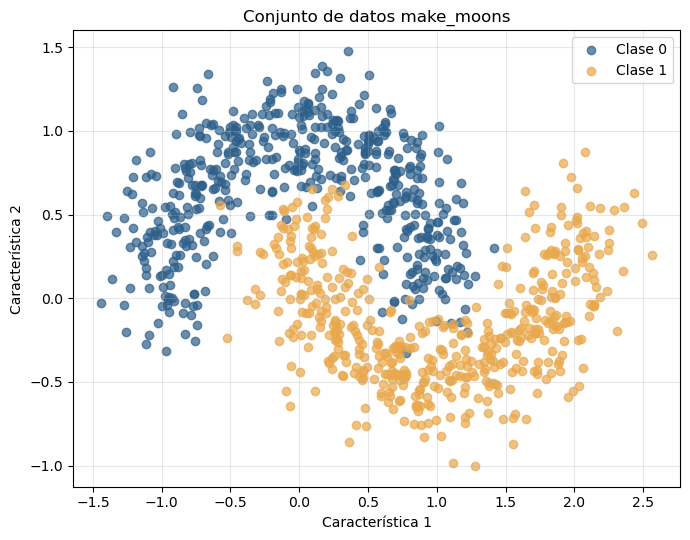

In [2]:
# Generación del dataset: dos clases en forma de medialunas entrelazadas (no separables linealmente)
X, y = make_moons(n_samples=1000, noise=0.20, random_state=42)
y = y.reshape(-1, 1)  # convertir a columna (n_samples, 1) para que combine bien con la salida de la red

# División en entrenamiento (80%) y prueba (20%), estratificada para mantener el balance de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado: media 0, desviación estándar 1 (ajustado solo con datos de entrenamiento para evitar fuga de información)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras | Características: {X_train.shape[1]}')

# Visualización del dataset completo
plt.figure(figsize=(7, 5.5))
plt.scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1], label='Clase 0', alpha=0.7, color=COLORS['sgd'])
plt.scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1], label='Clase 1', alpha=0.7, color=COLORS['rmsprop'])
plt.title('Conjunto de datos make_moons')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="seccion-2" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0;"><span style="display:inline-block; width:30px; height:30px; line-height:30px; text-align:center; background:#1B2A4A; color:#ffffff; border-radius:50%; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-weight:700; font-size:14px; vertical-align:middle;">2</span><span style="display:inline-block; margin-left:12px; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px; vertical-align:middle;">Implementación de la clase MLP</span></span>

<div style="background:#EAF1F8; border-left:4px solid #2C5F8A; border-radius:0 10px 10px 0; padding:18px 22px; margin:24px 0;">
<p style="margin:0 0 8px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:12.5px; font-weight:700; letter-spacing:1px; text-transform:uppercase; color:#2C5F8A;">SGD vs. RMSProp vs. Adam: &iquest;qué información usa cada uno?</p>
<p style="margin:0 0 12px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14.5px; line-height:1.65; color:#1B2A4A;">Los tres optimizadores actualizan los pesos en la dirección que reduce la pérdida. Sin embargo difieren en <strong>qué estadística del gradiente</strong> usan para decidir el tamaño del paso en cada parámetro:</p>
<ul style="margin:0; padding-left:20px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14.5px; line-height:1.8; color:#1B2A4A;">
<li><strong>SGD (gradiente puro):</strong> usa únicamente el gradiente actual (<code>g</code>) escalado por la tasa de aprendizaje: <code>W &larr; W - lr &middot; g</code>. No tiene memoria de gradientes pasados. Por eso aplica el mismo <code>lr</code> a todos los parámetros por igual, sin importar si su gradiente típico es grande o pequeño.</li>
<li><strong>RMSProp (promedio móvil del cuadrado del gradiente):</strong> mantiene un promedio móvil exponencial de <code>g&sup2;</code>, al que llama <code>v</code>, y divide el paso por <code>&radic;v</code>. Esto adapta la tasa de aprendizaje <em>por parámetro</em>. Los pesos con gradientes históricamente grandes reciben pasos más pequeños. Los que tienen gradientes históricamente pequeños reciben pasos más grandes. Así se estabiliza el entrenamiento en superficies de pérdida muy irregulares.</li>
<li><strong>Adam (momentum + promedio móvil del cuadrado del gradiente):</strong> combina las dos ideas anteriores. Mantiene un promedio móvil del gradiente (<code>m</code>): es el momentum y da una dirección suavizada. También mantiene un promedio móvil de <code>g&sup2;</code> (<code>v</code>): es la escala adaptativa, igual que en RMSProp. Ambos se corrigen por sesgo de inicialización. El paso final combina dirección suavizada con magnitud adaptativa: <code>W &larr; W - lr &middot; m&#770; / (&radic;v&#770; + &epsilon;)</code>.</li>
</ul>
</div>

In [3]:
class MLP:
    """
    Perceptrón multicapa con una única capa oculta (ReLU) y salida sigmoide,
    para clasificación binaria. Soporta tres optimizadores intercambiables:
    'sgd', 'rmsprop' y 'adam', seleccionables mediante el parámetro `optimizer`.
    """

    def __init__(self, n_input, n_hidden, n_output=1, optimizer='sgd',
                 learning_rate=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.optimizer = optimizer
        self.lr = learning_rate
        self.beta1 = beta1        # coeficiente del promedio móvil del gradiente (momentum, usado por Adam)
        self.beta2 = beta2        # coeficiente del promedio móvil del gradiente al cuadrado (usado por RMSProp y Adam)
        self.epsilon = epsilon    # constante pequeña para evitar división por cero

        # Inicialización de pesos: escala pequeña (0.01) para evitar activaciones saturadas al inicio;
        # los sesgos (bias) se inicializan en cero, práctica estándar porque no rompe la simetría por sí sola
        # pero al ir multiplicados por pesos distintos por neurona, no genera neuronas "gemelas"
        self.W1 = np.random.randn(n_input, n_hidden) * 0.01
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, n_output) * 0.01
        self.b2 = np.zeros((1, n_output))

        # Estado acumulado por el optimizador (promedios móviles), uno por cada matriz/vector de parámetros.
        # Se inicializan en cero y se van "calentando" a medida que se observan gradientes.
        self._init_optimizer_state()

    def _init_optimizer_state(self):
        # m: promedio móvil del gradiente (momentum) -- solo lo usa Adam
        # v: promedio móvil del gradiente al cuadrado -- lo usan RMSProp y Adam
        self.m = {k: np.zeros_like(getattr(self, k)) for k in ['W1', 'b1', 'W2', 'b2']}
        self.v = {k: np.zeros_like(getattr(self, k)) for k in ['W1', 'b1', 'W2', 'b2']}
        self.t = 0  # contador de pasos de actualización, necesario para la corrección de sesgo de Adam

    # ------------------------------------------------------------------
    # Funciones de activación
    # ------------------------------------------------------------------
    @staticmethod
    def _relu(z):
        return np.maximum(0, z)

    @staticmethod
    def _relu_derivative(z):
        return (z > 0).astype(float)  # derivada de ReLU: 1 donde z>0, 0 en el resto

    @staticmethod
    def _sigmoid(z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # clip evita overflow en exp() para |z| grandes

    # ------------------------------------------------------------------
    # Forward pass
    # ------------------------------------------------------------------
    def forward(self, X):
        """
        Propagación hacia adelante.
        z1 = X·W1 + b1        -> combinación lineal de entradas para la capa oculta
        a1 = ReLU(z1)         -> no linealidad que permite aprender fronteras curvas
        z2 = a1·W2 + b2       -> combinación lineal de la capa oculta hacia la salida
        a2 = sigmoide(z2)     -> probabilidad de pertenecer a la clase 1
        """
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self._relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self._sigmoid(self.z2)
        return self.a2

    @staticmethod
    def _bce_loss(y_true, y_pred):
        # Entropía cruzada binaria: -mean( y*log(p) + (1-y)*log(1-p) )
        eps = 1e-12  # evita log(0)
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    # ------------------------------------------------------------------
    # Backward pass
    # ------------------------------------------------------------------
    def backward(self, X, y_true):
        """
        Retropropagación: calcula el gradiente de la pérdida BCE respecto a cada
        parámetro, aplicando la regla de la cadena capa por capa (de salida a entrada).
        """
        n = X.shape[0]

        # Gradiente en la salida: para BCE + sigmoide, la derivada se simplifica a (a2 - y)
        dz2 = self.a2 - y_true                      # (n, n_output)
        dW2 = self.a1.T @ dz2 / n                    # gradiente respecto a W2
        db2 = np.sum(dz2, axis=0, keepdims=True) / n # gradiente respecto a b2

        # Propagar el error hacia la capa oculta
        da1 = dz2 @ self.W2.T                         # error retropropagado a las activaciones ocultas
        dz1 = da1 * self._relu_derivative(self.z1)    # aplicar derivada de ReLU (regla de la cadena)
        dW1 = X.T @ dz1 / n                            # gradiente respecto a W1
        db1 = np.sum(dz1, axis=0, keepdims=True) / n   # gradiente respecto a b1

        return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}

    # ------------------------------------------------------------------
    # Actualización de parámetros según el optimizador elegido
    # ------------------------------------------------------------------
    def _update(self, grads):
        self.t += 1  # incrementar el contador de pasos (usado por la corrección de sesgo de Adam)

        for key in ['W1', 'b1', 'W2', 'b2']:
            g = grads[key]
            param = getattr(self, key)

            if self.optimizer == 'sgd':
                # SGD puro: el paso es proporcional únicamente al gradiente actual
                param -= self.lr * g

            elif self.optimizer == 'rmsprop':
                # Promedio móvil exponencial de g^2: v = beta2*v + (1-beta2)*g^2
                self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * (g ** 2)
                # El paso se divide por la raíz de ese promedio -> tasa de aprendizaje adaptativa por parámetro
                param -= self.lr * g / (np.sqrt(self.v[key]) + self.epsilon)

            elif self.optimizer == 'adam':
                # Momentum: promedio móvil del gradiente (primer momento)
                self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * g
                # Promedio móvil del gradiente al cuadrado (segundo momento), igual que en RMSProp
                self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * (g ** 2)
                # Corrección de sesgo: al inicio m y v están sesgados hacia cero porque parten de 0
                m_hat = self.m[key] / (1 - self.beta1 ** self.t)
                v_hat = self.v[key] / (1 - self.beta2 ** self.t)
                # Paso final: dirección suavizada (m_hat) escalada de forma adaptativa (v_hat)
                param -= self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)

            else:
                raise ValueError(f"Optimizador desconocido: {self.optimizer}")

            setattr(self, key, param)

    # ------------------------------------------------------------------
    # Entrenamiento por mini-lotes
    # ------------------------------------------------------------------
    def train(self, X, y, epochs, batch_size, verbose=False):
        """
        Entrena la red por mini-lotes (mini-batch) durante `epochs` épocas.
        Devuelve la lista de pérdidas promedio por época.
        """
        n_samples = X.shape[0]
        loss_history = []

        for epoch in range(epochs):
            # Barajar los índices en cada época para que los lotes cambien de composición
            perm = np.random.permutation(n_samples)
            X_shuffled, y_shuffled = X[perm], y[perm]

            epoch_losses = []
            for start in range(0, n_samples, batch_size):
                end = start + batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                y_pred = self.forward(X_batch)                # forward
                loss = self._bce_loss(y_batch, y_pred)         # pérdida del lote
                grads = self.backward(X_batch, y_batch)        # backward (gradientes)
                self._update(grads)                             # actualización según el optimizador

                epoch_losses.append(loss)

            mean_loss = np.mean(epoch_losses)
            loss_history.append(mean_loss)

            if verbose and (epoch % 20 == 0 or epoch == epochs - 1):
                print(f'  Época {epoch:>4} | loss = {mean_loss:.4f}')

        return loss_history

    def predict(self, X):
        probs = self.forward(X)
        return (probs >= 0.5).astype(int)

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="seccion-3" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0;"><span style="display:inline-block; width:30px; height:30px; line-height:30px; text-align:center; background:#1B2A4A; color:#ffffff; border-radius:50%; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-weight:700; font-size:14px; vertical-align:middle;">3</span><span style="display:inline-block; margin-left:12px; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px; vertical-align:middle;">Experimento comparativo</span></span>

Entrenamos la misma arquitectura tres veces. Usamos la misma inicialización de pesos, el mismo `n_hidden`, el mismo `batch_size` y las mismas épocas. Solo cambiamos el optimizador. La tasa de aprendizaje (`lr`) se ajusta por optimizador y queda documentada explícitamente en el diccionario `LEARNING_RATES`. SGD no reescala el paso según la magnitud del gradiente. Por eso necesita un `lr` bastante mayor que RMSProp o Adam. De lo contrario se queda casi estancado en 200 épocas.

In [4]:
# Hiperparámetros base compartidos por los tres optimizadores
N_HIDDEN = 16
EPOCHS = 200
BATCH_SIZE = 32

# Tasa de aprendizaje por optimizador. En principio usamos el mismo lr para los tres,
# pero SGD con lr=0.01 (habitual en Adam/RMSProp) prácticamente no se mueve en 200 épocas:
# al no reescalar el paso por la magnitud típica del gradiente, necesita un lr mucho mayor
# para ser competitivo. Por eso el lr se ajusta por optimizador, de forma explícita:
LEARNING_RATES = {
    'sgd': 0.5,
    'rmsprop': 0.03,
    'adam': 0.03,
}

results = {}  # aquí guardamos, por optimizador: historial de loss, tiempo de entrenamiento y precisión en test

for opt_name in ['sgd', 'rmsprop', 'adam']:
    print(f'Entrenando con {NAMES[opt_name]} (lr={LEARNING_RATES[opt_name]}) ...')

    # Semilla fija antes de crear cada modelo: los tres parten de la MISMA inicialización de pesos,
    # así cualquier diferencia en la convergencia se debe al optimizador y no al azar de la inicialización
    np.random.seed(0)
    model = MLP(
        n_input=X_train.shape[1],
        n_hidden=N_HIDDEN,
        n_output=1,
        optimizer=opt_name,
        learning_rate=LEARNING_RATES[opt_name],
    )

    start_time = time.time()                                        # marca de tiempo inicial
    loss_history = model.train(X_train, y_train, EPOCHS, BATCH_SIZE) # entrenamiento
    elapsed = time.time() - start_time                               # tiempo total de entrenamiento en segundos

    y_pred_test = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    results[opt_name] = {
        'loss_history': loss_history,
        'train_time': elapsed,
        'test_accuracy': test_acc,
        'model': model,
    }

    print(f'  -> tiempo: {elapsed:.3f} s | loss final: {loss_history[-1]:.4f} | accuracy test: {test_acc:.4f}\n')

Entrenando con SGD (lr=0.5) ...


  -> tiempo: 0.353 s | loss final: 0.1112 | accuracy test: 0.9900

Entrenando con RMSProp (lr=0.03) ...


  -> tiempo: 0.466 s | loss final: 0.1238 | accuracy test: 0.9700

Entrenando con Adam (lr=0.03) ...


  -> tiempo: 0.544 s | loss final: 0.1053 | accuracy test: 0.9850



<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="seccion-4" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0;"><span style="display:inline-block; width:30px; height:30px; line-height:30px; text-align:center; background:#1B2A4A; color:#ffffff; border-radius:50%; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-weight:700; font-size:14px; vertical-align:middle;">4</span><span style="display:inline-block; margin-left:12px; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px; vertical-align:middle;">Resultados</span></span>

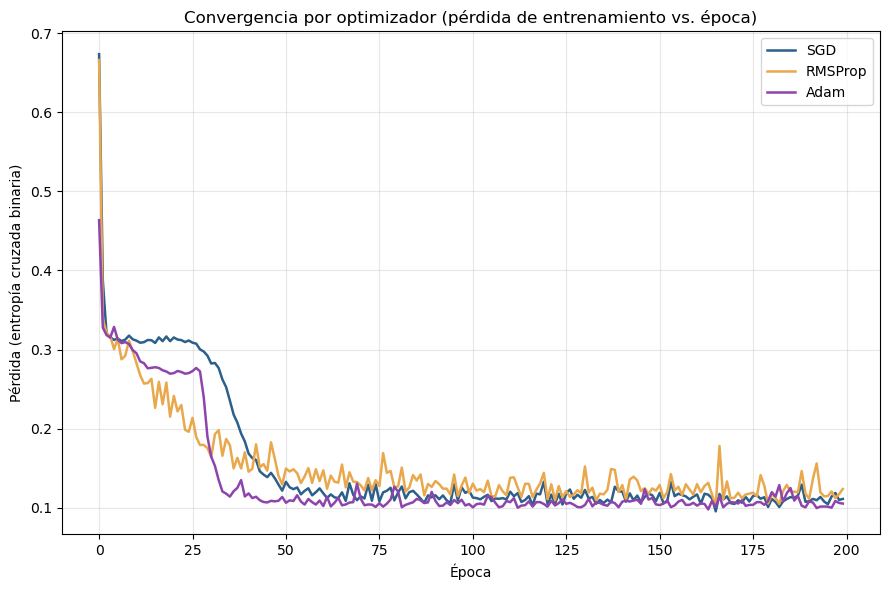

In [5]:
# Curva de convergencia: loss vs. época, con las tres curvas superpuestas
plt.figure(figsize=(9, 6))
for opt_name in ['sgd', 'rmsprop', 'adam']:
    plt.plot(
        results[opt_name]['loss_history'],
        label=NAMES[opt_name],
        color=COLORS[opt_name],
        linewidth=1.8,
    )
plt.title('Convergencia por optimizador (pérdida de entrenamiento vs. época)')
plt.xlabel('Época')
plt.ylabel('Pérdida (entropía cruzada binaria)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

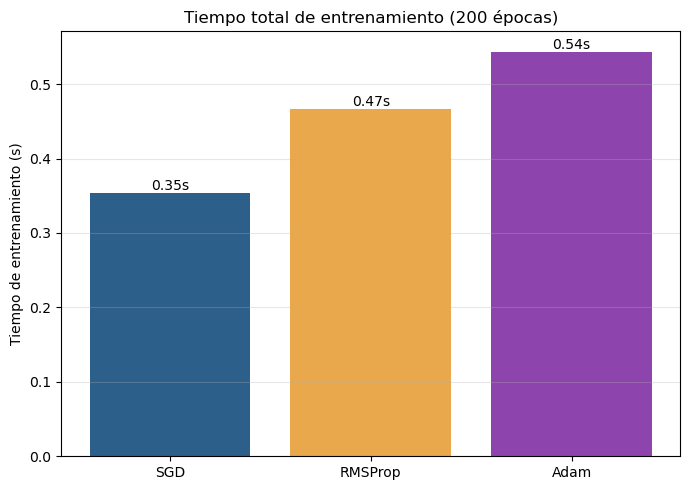

In [6]:
# Gráfica de barras: tiempo total de entrenamiento por optimizador
opt_order = ['sgd', 'rmsprop', 'adam']
times = [results[o]['train_time'] for o in opt_order]
bar_colors = [COLORS[o] for o in opt_order]

plt.figure(figsize=(7, 5))
bars = plt.bar([NAMES[o] for o in opt_order], times, color=bar_colors)
plt.ylabel('Tiempo de entrenamiento (s)')
plt.title(f'Tiempo total de entrenamiento ({EPOCHS} épocas)')
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{t:.2f}s',
              ha='center', va='bottom', fontsize=10)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Tabla resumen: tiempo de entrenamiento, loss final y precisión en test por optimizador
header = f"{'Optimizador':<12}{'Tiempo (s)':>14}{'Loss final':>14}{'Accuracy test':>16}"
print(header)
print('-' * len(header))
for opt_name in opt_order:
    r = results[opt_name]
    print(f"{NAMES[opt_name]:<12}{r['train_time']:>14.3f}{r['loss_history'][-1]:>14.4f}{r['test_accuracy']:>16.4f}")

Optimizador     Tiempo (s)    Loss final   Accuracy test
--------------------------------------------------------
SGD                  0.353        0.1112          0.9900
RMSProp              0.466        0.1238          0.9700
Adam                 0.544        0.1053          0.9850


<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="seccion-5" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0;"><span style="display:inline-block; width:30px; height:30px; line-height:30px; text-align:center; background:#1B2A4A; color:#ffffff; border-radius:50%; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-weight:700; font-size:14px; vertical-align:middle;">5</span><span style="display:inline-block; margin-left:12px; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px; vertical-align:middle;">Interpretación</span></span>

<div style="background:#FBF0DC; border-left:4px solid #E9A84C; border-radius:0 10px 10px 0; padding:18px 22px; margin:24px 0;">
<p style="margin:0 0 8px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:12.5px; font-weight:700; letter-spacing:1px; text-transform:uppercase; color:#8a5a12;">Análisis de resultados</p>
<p style="margin:0 0 12px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14.5px; line-height:1.7; color:#5c4315;"><strong style="color:#8a5a12;">Convergencia en épocas:</strong> Adam y RMSProp arrancan mucho más rápido que SGD. Adam cruza una pérdida de 0.3 alrededor de la <strong style="color:#8a5a12;">época 9</strong>. RMSProp cruza ese mismo nivel cerca de la <strong style="color:#8a5a12;">época 6</strong>. SGD tarda hasta la <strong style="color:#8a5a12;">época 28</strong> en llegar ahí. Su paso es fijo y no se reescala según la magnitud del gradiente. Por eso avanza más lento en la fase inicial, cuando el gradiente todavía es pequeño y está cerca de la inicialización. Aun así, SGD también termina convergiendo bien: cruza una pérdida de 0.15 hacia la época 43, y Adam cruza ese mismo umbral casi al mismo tiempo, alrededor de la época 32. En las épocas finales Adam logra el <strong style="color:#8a5a12;">loss final más bajo</strong> de los tres. SGD queda muy cerca en segundo lugar. RMSProp se queda un poco por detrás de ambos.</p>
<p style="margin:0 0 12px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14.5px; line-height:1.7; color:#5c4315;"><strong style="color:#8a5a12;">Tiempo real (wall-clock):</strong> por época, SGD es el más barato computacionalmente. Solo calcula <code>g</code> y aplica un producto escalar. RMSProp y, sobre todo, Adam cargan un costo extra: deben mantener y actualizar promedios móviles (<code>v</code> en ambos casos, y además <code>m</code> en el caso de Adam, más la corrección de sesgo en cada paso). En la tabla de la Sección 4 se observa justamente ese orden. SGD es el más rápido en segundos totales. RMSProp queda en un punto intermedio. Adam es el más lento de los tres, pese a converger en menos épocas. Es decir: &ldquo;menos épocas para converger&rdquo; y &ldquo;menos segundos de reloj&rdquo; <strong style="color:#8a5a12;">no son la misma noción de velocidad</strong>. En este experimento, con una red tan pequeña (16 neuronas ocultas y 2 entradas), el costo extra por paso de Adam pesa más que el ahorro en número de épocas.</p>
<p style="margin:0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14.5px; line-height:1.7; color:#5c4315;"><strong style="color:#8a5a12;">Estabilidad vs. velocidad:</strong> miremos ahora la variabilidad de la pérdida en las últimas épocas, una vez que cada curva ya se aplanó. <strong style="color:#8a5a12;">RMSProp es el que más oscila</strong>. Su desviación estándar en la cola es más del doble que la de SGD o Adam. También presenta el salto puntual más grande entre épocas consecutivas. <strong style="color:#8a5a12;">Adam, en cambio, es tan estable como SGD</strong> pese a converger mucho antes. El momentum ayuda a explicar esto: es el promedio móvil del gradiente, no solo de su cuadrado, y suaviza la dirección del paso. Así evita parte del ruido que sí afecta a RMSProp. El patrón que deja este experimento es claro. La ganancia en velocidad de convergencia de los optimizadores adaptativos no es gratuita ni uniforme. RMSProp la paga con más oscilación cerca del mínimo. Adam casi no la paga en estabilidad, pero sí en costo por paso. SGD es el más lento en arrancar. Aun así es el más barato de ejecutar. Y termina siendo muy competitivo en precisión final, una vez que dispone de suficientes épocas y de un <code>lr</code> bien ajustado a su naturaleza no adaptativa.</p>
</div>

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="referencias" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px;">Referencias</span>

<div style="background:#EAF1F8; border-radius:0 0 10px 10px; padding:16px 22px;">
<ol style="margin:0; padding-left:20px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14px; line-height:1.9; color:#1B2A4A;">
<li>Ruder, S. (2016). <em>An overview of gradient descent optimization algorithms</em>. arXiv:1609.04747. <a href="https://arxiv.org/abs/1609.04747" style="color:#2C5F8A; font-weight:600;">arxiv.org/abs/1609.04747</a></li>
<li>Kingma, D. P., &amp; Ba, J. (2014). <em>Adam: A Method for Stochastic Optimization</em>. arXiv:1412.6980. <a href="https://arxiv.org/abs/1412.6980" style="color:#2C5F8A; font-weight:600;">arxiv.org/abs/1412.6980</a></li>
<li>Goodfellow, I., Bengio, Y., &amp; Courville, A. (2016). <em>Deep Learning</em>. MIT Press. <a href="https://www.deeplearningbook.org/" style="color:#2C5F8A; font-weight:600;">deeplearningbook.org</a></li>
</ol>
</div>

<div style="background:#1B2A4A; border-radius:10px; padding:20px; margin:28px 0 6px 0; text-align:center;">
<span style="color:#cfd7e6; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:13.5px; letter-spacing:.3px;">&copy; <strong style="color:#ffffff;">Carolina Luque</strong> &mdash; Deep Learning</span>
</div>